In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math


# =========================================================
# 1. Simple form classification rule
# =========================================================

def classify_curve_shape_simple(
    x_curve,
    y_curve,
    y_raw_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.70,
    min_net_change_ratio=0.10,
    turning_amplitude_ratio=0.10,
    side_fraction_threshold=0.60,
    roughness_max=3.0,
):
    """
    Simplified form classification for fitted response curves.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex / uncertain nonlinear

    Intended use:
    Apply to fitted curves, not directly to noisy raw scatter points.
    """

    # -----------------------------------------------------
    # 1. Input cleaning
    # -----------------------------------------------------
    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # -----------------------------------------------------
    # 2. Flat / negligible response gate before normalization
    # -----------------------------------------------------
    flat_gate_used = (
        y_raw_std is not None
        and np.isfinite(y_raw_std)
        and y_raw_std > 0
    )

    if flat_gate_used:
        y_range_to_obs_std = y_range_raw / y_raw_std

        if y_range_to_obs_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_raw_std": y_raw_std,
                "y_range_to_obs_std": y_range_to_obs_std,
                "flat_gate_used": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_raw_std": y_raw_std,
            "y_range_to_obs_std": np.nan,
            "flat_gate_used": False,
        }

    # -----------------------------------------------------
    # 3. Normalize x and y
    # -----------------------------------------------------
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_raw_std": y_raw_std,
            "y_range_to_obs_std": (
                y_range_raw / y_raw_std if flat_gate_used else np.nan
            ),
            "flat_gate_used": flat_gate_used,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # -----------------------------------------------------
    # 4. Local slopes
    # -----------------------------------------------------
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1
    signs[np.abs(slopes) <= slope_tol] = 0

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # -----------------------------------------------------
    # 5. Net change and roughness
    # -----------------------------------------------------
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # -----------------------------------------------------
    # 6. Tolerant U / inverted-U detection
    # -----------------------------------------------------
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    valley_is_internal = 0 < min_idx < len(y_norm) - 1
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

    # U-shaped: left side mostly decreasing/flat, right side mostly increasing/flat
    left_signs_to_min = signs[:max(min_idx, 1)]
    right_signs_from_min = signs[min_idx:]

    if len(left_signs_to_min) > 0:
        left_neg_or_flat = float(np.mean((left_signs_to_min == -1) | (left_signs_to_min == 0)))
    else:
        left_neg_or_flat = 0.0

    if len(right_signs_from_min) > 0:
        right_pos_or_flat = float(np.mean((right_signs_from_min == 1) | (right_signs_from_min == 0)))
    else:
        right_pos_or_flat = 0.0

    u_shape_candidate = (
        valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
        and left_neg_or_flat >= side_fraction_threshold
        and right_pos_or_flat >= side_fraction_threshold
    )

    # Inverted-U: left side mostly increasing/flat, right side mostly decreasing/flat
    left_signs_to_max = signs[:max(max_idx, 1)]
    right_signs_from_max = signs[max_idx:]

    if len(left_signs_to_max) > 0:
        left_pos_or_flat = float(np.mean((left_signs_to_max == 1) | (left_signs_to_max == 0)))
    else:
        left_pos_or_flat = 0.0

    if len(right_signs_from_max) > 0:
        right_neg_or_flat = float(np.mean((right_signs_from_max == -1) | (right_signs_from_max == 0)))
    else:
        right_neg_or_flat = 0.0

    inverted_u_candidate = (
        peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
        and left_pos_or_flat >= side_fraction_threshold
        and right_neg_or_flat >= side_fraction_threshold
    )

    # -----------------------------------------------------
    # 7. Decision tree
    # -----------------------------------------------------
    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    elif (
        n_sign_changes >= 2
        or roughness_ratio > roughness_max
    ):
        shape_type = "Complex / uncertain nonlinear"

    else:
        shape_type = "Complex / uncertain nonlinear"

    return {
        "shape_type": shape_type,
        "y_range_raw": y_range_raw,
        "y_raw_std": y_raw_std,
        "y_range_to_obs_std": (
            y_range_raw / y_raw_std if flat_gate_used else np.nan
        ),
        "flat_gate_used": flat_gate_used,
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "roughness_ratio": roughness_ratio,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "left_neg_or_flat": left_neg_or_flat,
        "right_pos_or_flat": right_pos_or_flat,
        "left_pos_or_flat": left_pos_or_flat,
        "right_neg_or_flat": right_neg_or_flat,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
    }

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from scipy.stats import spearmanr


def make_curve(func, x_range=(0, 1), n=120, noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(*x_range, n)
    y_true = func(x)
    y = y_true + noise * rng.standard_normal(n)
    return x, y, y_true


y_raw_std = 1.0


basic_test_cases_simple = [
    (
        "Linear increase",
        lambda x: 0.5 * x,
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Linear decrease",
        lambda x: -0.5 * x,
        (0, 2),
        "Monotonic decrease",
    ),
    (
        "Saturating increase: 1 - exp(-3x)",
        lambda x: 1 - np.exp(-3 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Saturating increase: log(1 + 5x)",
        lambda x: np.log(1 + 5 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Saturating decrease",
        lambda x: np.exp(-3 * x),
        (0, 2),
        "Monotonic decrease",
    ),
    (
        "U-shaped",
        lambda x: (x - 1.0) ** 2,
        (0, 2),
        "U-shaped",
    ),
    (
        "Inverted-U-shaped",
        lambda x: 1.0 - (x - 1.0) ** 2,
        (0, 2),
        "Inverted-U-shaped",
    ),
    (
        "Flat negligible response",
        lambda x: 0.001 * x,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Complex oscillation",
        lambda x: np.sin(3 * np.pi * x),
        (0, 2),
        "Complex / uncertain nonlinear",
    ),
]


edge_test_cases_simple = [
    (
        "Monotonic plus tiny early dip",
        lambda x: x - 0.005 * np.exp(-50 * (x - 0.05) ** 2),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Nearly flat weak trend",
        lambda x: 0.01 * x,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Weak saturating increase but not flat",
        lambda x: 0.08 * (1 - np.exp(-3 * x)),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Monotonic increase with small wiggles",
        lambda x: x + 0.03 * np.sin(8 * np.pi * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Shallow U-shaped but meaningful",
        lambda x: 0.20 * (x - 1.0) ** 2,
        (0, 2),
        "U-shaped",
    ),
    (
        "Very shallow U should be flat",
        lambda x: 0.02 * (x - 1.0) ** 2,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Asymmetric U-shaped",
        lambda x: np.where(
            x < 1.0,
            (x - 1.0) ** 2,
            0.35 * (x - 1.0) ** 2
        ),
        (0, 2),
        "U-shaped",
    ),
    (
        "Mild log saturation",
        lambda x: np.log1p(1.5 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Increasing with strong oscillation",
        lambda x: x + 0.20 * np.sin(6 * np.pi * x),
        (0, 2),
        "Complex / uncertain nonlinear",
    ),
    (
        "Late acceleration increase",
        lambda x: x ** 2,
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Late acceleration decrease",
        lambda x: 1 - x ** 2,
        (0, 1),
        "Monotonic decrease",
    ),
]


all_test_cases_simple = basic_test_cases_simple + edge_test_cases_simple

In [15]:
def smooth_curve_moving_average(y, window=31):
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y.copy()

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window < 3:
        return y.copy()

    if window % 2 == 0:
        window += 1

    pad = window // 2
    kernel = np.ones(window) / window
    y_pad = np.pad(y, pad_width=pad, mode="reflect")
    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    return y_smooth

In [16]:
def print_test_summary_simple(df, title):
    n_pass = int(df["ok"].sum())
    n_total = len(df)

    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    print(f"Pass rate: {n_pass}/{n_total} = {100 * n_pass / n_total:.1f}%")

    failed = df[df["ok"] == False]

    if len(failed) > 0:
        print("\nFailed cases:")
        display_cols = [
            "test_name",
            "expected",
            "got",
            "net_change",
            "pos_fraction",
            "neg_fraction",
            "flat_fraction",
            "n_sign_changes",
            "roughness_ratio",
            "y_range_to_obs_std"
        ]
        display_cols = [c for c in display_cols if c in failed.columns]
        print(failed[display_cols].to_string(index=False))
    else:
        print("All tests passed.")


def run_clean_tests_simple(test_cases=all_test_cases_simple):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y, y_true = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=0.0
        )

        result = classify_curve_shape_simple(
            x,
            y,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "clean_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, "Clean fitted curves")
    return df


def run_noisy_raw_tests_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    seed=42
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=noise,
            seed=seed
        )

        result = classify_curve_shape_simple(
            x,
            y_noisy,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_raw_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, f"Noisy raw curves, noise={noise}")
    return df


def run_noisy_smoothed_tests_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    seed=42,
    smooth_window=31
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_fit = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        x_curve = x[::3]
        y_curve = y_fit[::3]

        result = classify_curve_shape_simple(
            x_curve,
            y_curve,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_smoothed_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            "smooth_window": smooth_window,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, f"Noisy → smoothed curves, noise={noise}")
    return df


def compare_test_results_simple(*dfs):
    compare_df = pd.concat(dfs, ignore_index=True)

    summary = (
        compare_df
        .groupby("test_group")["ok"]
        .agg(["sum", "count"])
        .reset_index()
    )

    summary["pass_rate"] = summary["sum"] / summary["count"]
    summary["pass_rate_percent"] = (summary["pass_rate"] * 100).round(1)

    return compare_df, summary

In [17]:
clean_df_simple = run_clean_tests_simple()

noisy_raw_df_simple = run_noisy_raw_tests_simple(
    noise=0.04
)

noisy_smoothed_df_simple = run_noisy_smoothed_tests_simple(
    noise=0.04,
    smooth_window=31
)

compare_df_simple, summary_df_simple = compare_test_results_simple(
    clean_df_simple,
    noisy_raw_df_simple,
    noisy_smoothed_df_simple
)

summary_df_simple


Clean fitted curves
Pass rate: 20/20 = 100.0%
All tests passed.

Noisy raw curves, noise=0.04
Pass rate: 6/20 = 30.0%

Failed cases:
                            test_name                   expected                           got  net_change  pos_fraction  neg_fraction  flat_fraction  n_sign_changes  roughness_ratio  y_range_to_obs_std
                      Linear increase         Monotonic increase Complex / uncertain nonlinear    0.889229      0.630252      0.361345       0.008403              72         4.378418            1.100096
                      Linear decrease         Monotonic decrease Complex / uncertain nonlinear   -0.999000      0.428571      0.563025       0.008403              80         4.098778            1.022786
    Saturating increase: 1 - exp(-3x)         Monotonic increase Complex / uncertain nonlinear    0.925861      0.588235      0.394958       0.016807              74         4.398988            1.053893
     Saturating increase: log(1 + 5x)         Monotoni

,test_group,sum,count,pass_rate,pass_rate_percent
0,clean_curve,20,20,1.00,100.0
1,noisy_raw_curve,6,20,0.30,30.0
2,noisy_smoothed_curve,19,20,0.95,95.0


In [18]:
def plot_test_comparison_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    smooth_window=31,
    n_cols=2,
    figsize_per_panel=(6.5, 4.8),
    seed=42,
    title_fontsize=13,
    text_fontsize=10.5,
    axis_label_fontsize=11.5,
    tick_fontsize=10.5,
    legend_fontsize=11.5
):
    n_cases = len(test_cases)
    n_rows = math.ceil(n_cases / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        dpi=160
    )

    axes = np.asarray(axes).reshape(-1)

    for i, (name, func, xr, expected) in enumerate(test_cases):
        ax = axes[i]

        x_clean, y_clean, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=0.0
        )

        x_noisy, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_smooth = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        clean_result = classify_curve_shape_simple(
            x_clean,
            y_clean,
            y_raw_std=y_raw_std
        )

        noisy_result = classify_curve_shape_simple(
            x_noisy,
            y_noisy,
            y_raw_std=y_raw_std
        )

        smooth_result = classify_curve_shape_simple(
            x_noisy,
            y_smooth,
            y_raw_std=y_raw_std
        )

        clean_label = clean_result["shape_type"]
        noisy_label = noisy_result["shape_type"]
        smooth_label = smooth_result["shape_type"]

        ax.plot(
            x_clean,
            y_clean,
            linewidth=2.2,
            color="black",
            label="Clean curve",
            zorder=3
        )

        ax.scatter(
            x_noisy,
            y_noisy,
            s=9,
            alpha=0.25,
            color="0.55",
            linewidths=0,
            label="Noisy raw",
            zorder=1
        )

        ax.plot(
            x_noisy,
            y_smooth,
            linewidth=2.0,
            color="tab:blue",
            label="Noisy → smoothed",
            zorder=4
        )

        text = (
            f"Expected: {expected}\n"
            f"Clean: {clean_label}\n"
            f"Noisy raw: {noisy_label}\n"
            f"Noisy→smooth: {smooth_label}"
        )

        ok_clean = clean_label == expected
        ok_smooth = smooth_label == expected

        title_color = "black" if ok_clean and ok_smooth else "crimson"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=text_fontsize,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            ),
            zorder=10
        )

        ax.set_title(
            name,
            fontsize=title_fontsize,
            color=title_color,
            pad=8
        )

        ax.set_xlabel("x", fontsize=axis_label_fontsize)
        ax.set_ylabel("response", fontsize=axis_label_fontsize)

        ax.grid(
            True,
            which="major",
            color="0.85",
            linewidth=0.7
        )

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.8)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
            length=3.5,
            width=0.8,
            color="0.35"
        )

    for j in range(n_cases, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        fontsize=legend_fontsize,
        frameon=True,
        bbox_to_anchor=(0.5, -0.005)
    )

    fig.suptitle(
        "Simple form classification tests: clean vs noisy raw vs noisy-smoothed curves",
        fontsize=16,
        y=0.995
    )

    plt.tight_layout(rect=[0, 0.015, 1, 0.975])

    fig.subplots_adjust(
        wspace=0.18,
        hspace=0.25
    )


    plt.show()

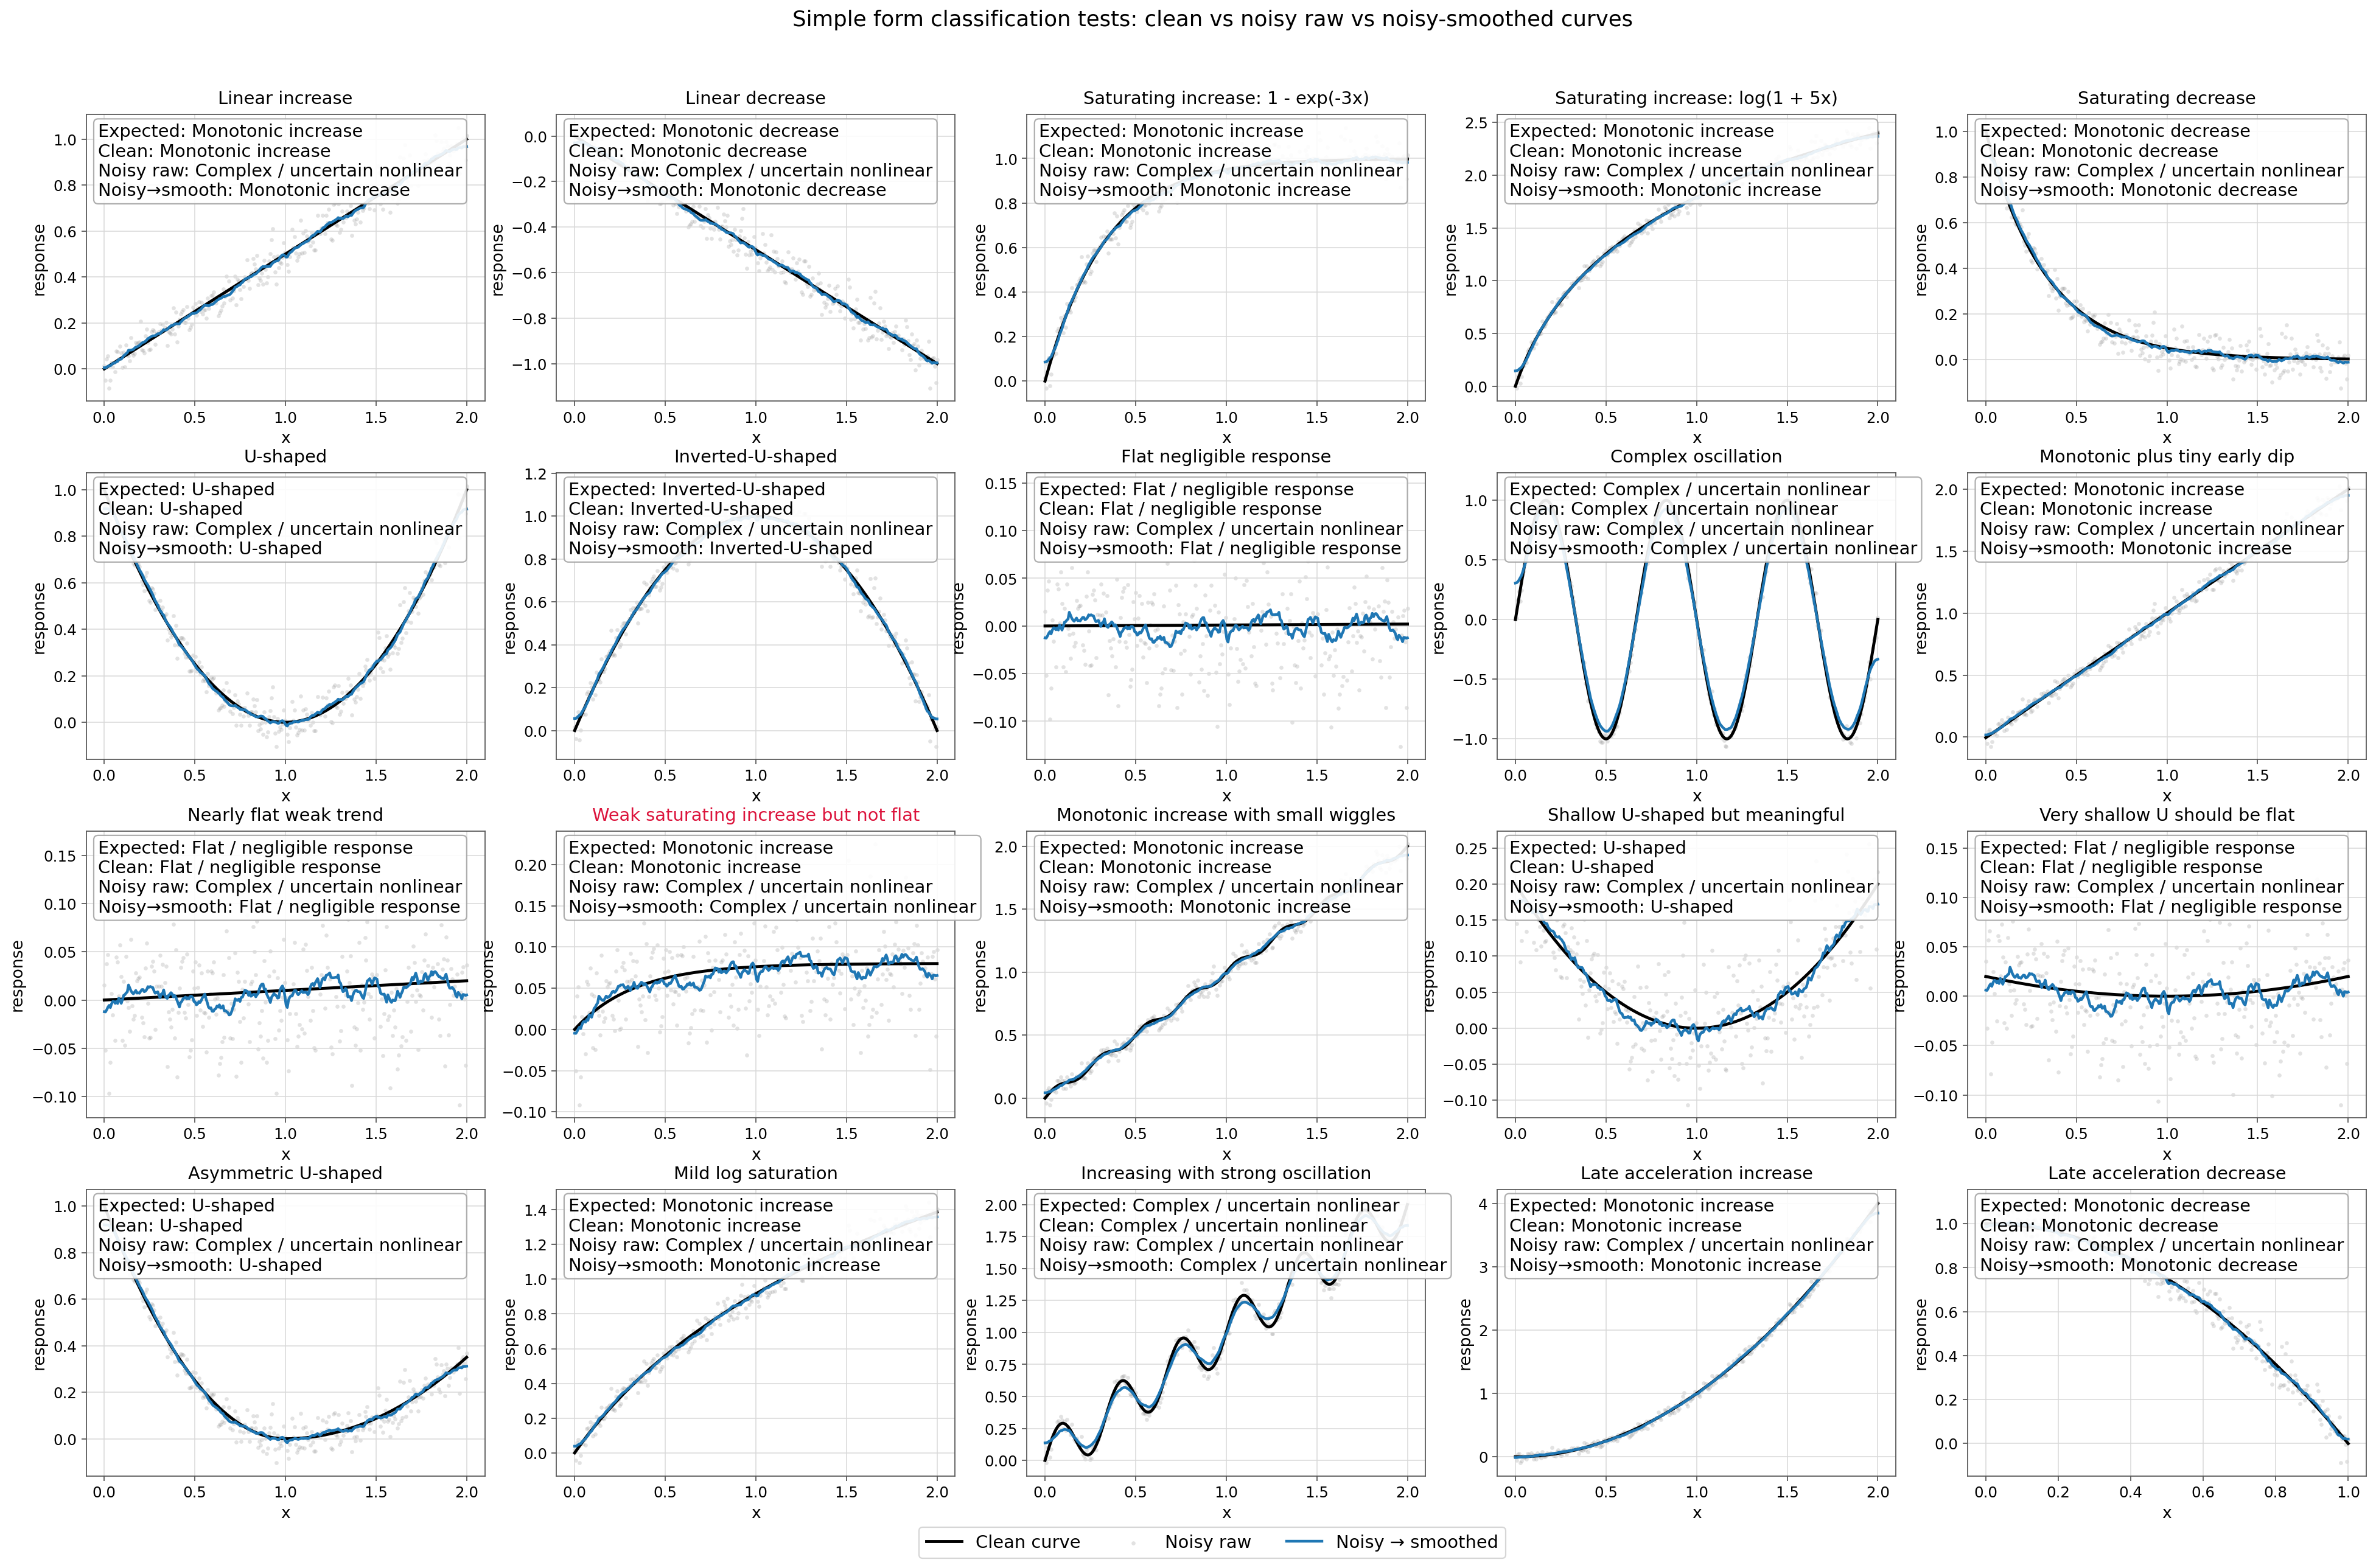

In [19]:
plot_test_comparison_simple(
    test_cases=all_test_cases_simple,
    noise=0.05,
    smooth_window=20,
    n_cols=5,
    figsize_per_panel=(5, 4),
    text_fontsize=13,
    title_fontsize=13,
    axis_label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=13
)

In [47]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, norm
import statsmodels.api as sm
from sklearn.isotonic import IsotonicRegression


# =========================================================
# 1. Curve shape classifier
# =========================================================

def classify_curve_shape(
    x_curve,
    y_curve,
    y_raw_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.70,
    min_net_change_ratio=0.10,
    turning_amplitude_ratio=0.10,
    side_fraction_threshold=0.60,
    roughness_max=3.0,
):
    """
    Classify the shape of a fitted response curve.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex / uncertain nonlinear
    - Insufficient data

    Note:
    This function should be applied to fitted curves, not directly to raw scatter points.
    """

    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # -----------------------------------------------------
    # S1: Pre-check — response amplitude
    # -----------------------------------------------------
    raw_scale_available = (
        y_raw_std is not None
        and np.isfinite(y_raw_std)
        and y_raw_std > 0
    )

    if raw_scale_available:
        y_range_to_raw_std = y_range_raw / y_raw_std

        if y_range_to_raw_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_raw_std": y_raw_std,
                "y_range_to_raw_std": y_range_to_raw_std,
                "raw_scale_available": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_raw_std": y_raw_std,
            "y_range_to_raw_std": np.nan,
            "raw_scale_available": False,
        }

    # -----------------------------------------------------
    # Normalize x and y after pre-check
    # -----------------------------------------------------
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_raw_std": y_raw_std,
            "y_range_to_raw_std": (
                y_range_raw / y_raw_std if raw_scale_available else np.nan
            ),
            "raw_scale_available": raw_scale_available,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # -----------------------------------------------------
    # Local slopes
    # -----------------------------------------------------
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1
    signs[np.abs(slopes) <= slope_tol] = 0

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # -----------------------------------------------------
    # S2: Overall direction
    # -----------------------------------------------------
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # -----------------------------------------------------
    # S3: Major turning point
    # -----------------------------------------------------
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    valley_is_internal = 0 < min_idx < len(y_norm) - 1
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

    # U-shaped: left side mostly decreasing/flat, right side mostly increasing/flat
    left_signs_to_min = signs[:max(min_idx, 1)]
    right_signs_from_min = signs[min_idx:]

    if len(left_signs_to_min) > 0:
        left_neg_or_flat = float(np.mean((left_signs_to_min == -1) | (left_signs_to_min == 0)))
    else:
        left_neg_or_flat = 0.0

    if len(right_signs_from_min) > 0:
        right_pos_or_flat = float(np.mean((right_signs_from_min == 1) | (right_signs_from_min == 0)))
    else:
        right_pos_or_flat = 0.0

    u_shape_candidate = (
        valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
        and left_neg_or_flat >= side_fraction_threshold
        and right_pos_or_flat >= side_fraction_threshold
    )

    # Inverted-U: left side mostly increasing/flat, right side mostly decreasing/flat
    left_signs_to_max = signs[:max(max_idx, 1)]
    right_signs_from_max = signs[max_idx:]

    if len(left_signs_to_max) > 0:
        left_pos_or_flat = float(np.mean((left_signs_to_max == 1) | (left_signs_to_max == 0)))
    else:
        left_pos_or_flat = 0.0

    if len(right_signs_from_max) > 0:
        right_neg_or_flat = float(np.mean((right_signs_from_max == -1) | (right_signs_from_max == 0)))
    else:
        right_neg_or_flat = 0.0

    inverted_u_candidate = (
        peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
        and left_pos_or_flat >= side_fraction_threshold
        and right_neg_or_flat >= side_fraction_threshold
    )

    # -----------------------------------------------------
    # Decision tree
    # -----------------------------------------------------
    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    elif (
        n_sign_changes >= 2
        or roughness_ratio > roughness_max
    ):
        shape_type = "Complex / uncertain nonlinear"

    else:
        shape_type = "Complex / uncertain nonlinear"

    return {
        "shape_type": shape_type,

        # S1
        "y_range_raw": y_range_raw,
        "y_raw_std": y_raw_std,
        "y_range_to_raw_std": (
            y_range_raw / y_raw_std if raw_scale_available else np.nan
        ),
        "raw_scale_available": raw_scale_available,

        # S2
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "roughness_ratio": roughness_ratio,

        # S3
        "valley_is_internal": valley_is_internal,
        "peak_is_internal": peak_is_internal,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "left_neg_or_flat": left_neg_or_flat,
        "right_pos_or_flat": right_pos_or_flat,
        "left_pos_or_flat": left_pos_or_flat,
        "right_neg_or_flat": right_neg_or_flat,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
    }


# =========================================================
# 2. Synthetic test cases
# =========================================================

def make_curve(func, x_range=(0, 1), n=120, noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(*x_range, n)
    y_true = func(x)
    y = y_true + noise * rng.standard_normal(n)
    return x, y, y_true


y_raw_std = 1.0


basic_test_cases = [
    ("Linear increase", lambda x: 0.5 * x, (0, 2), "Monotonic increase"),
    ("Linear decrease", lambda x: -0.5 * x, (0, 2), "Monotonic decrease"),
    ("Saturating increase: 1 - exp(-3x)", lambda x: 1 - np.exp(-3 * x), (0, 2), "Monotonic increase"),
    ("Saturating increase: log(1 + 5x)", lambda x: np.log(1 + 5 * x), (0, 2), "Monotonic increase"),
    ("Saturating decrease", lambda x: np.exp(-3 * x), (0, 2), "Monotonic decrease"),
    ("U-shaped", lambda x: (x - 1.0) ** 2, (0, 2), "U-shaped"),
    ("Inverted-U-shaped", lambda x: 1.0 - (x - 1.0) ** 2, (0, 2), "Inverted-U-shaped"),
    ("Flat negligible response", lambda x: 0.001 * x, (0, 2), "Flat / negligible response"),
    ("Complex oscillation", lambda x: np.sin(3 * np.pi * x), (0, 2), "Complex / uncertain nonlinear"),
]


edge_test_cases = [
    ("Monotonic plus tiny early dip", lambda x: x - 0.005 * np.exp(-50 * (x - 0.05) ** 2), (0, 2), "Monotonic increase"),
    ("Nearly flat weak trend", lambda x: 0.01 * x, (0, 2), "Flat / negligible response"),
    ("Weak saturating increase but not flat", lambda x: 0.08 * (1 - np.exp(-3 * x)), (0, 2), "Monotonic increase"),
    ("Monotonic increase with small wiggles", lambda x: x + 0.03 * np.sin(8 * np.pi * x), (0, 2), "Monotonic increase"),
    ("Shallow U-shaped but meaningful", lambda x: 0.20 * (x - 1.0) ** 2, (0, 2), "U-shaped"),
    ("Very shallow U should be flat", lambda x: 0.02 * (x - 1.0) ** 2, (0, 2), "Flat / negligible response"),
    (
        "Asymmetric U-shaped",
        lambda x: np.where(
            x < 1.0,
            (x - 1.0) ** 2,
            0.35 * (x - 1.0) ** 2
        ),
        (0, 2),
        "U-shaped",
    ),
    ("Mild log saturation", lambda x: np.log1p(1.5 * x), (0, 2), "Monotonic increase"),
    ("Increasing with strong oscillation", lambda x: x + 0.20 * np.sin(6 * np.pi * x), (0, 2), "Complex / uncertain nonlinear"),
    ("Late acceleration increase", lambda x: x ** 2, (0, 2), "Monotonic increase"),
    ("Late acceleration decrease", lambda x: 1 - x ** 2, (0, 1), "Monotonic decrease"),
]


all_test_cases = basic_test_cases + edge_test_cases


# Backward-compatible name if you used this before
all_test_cases_simple = all_test_cases


# =========================================================
# 3. Smoothing for noisy fitted-curve simulation
# =========================================================

def smooth_curve_moving_average(y, window=31):
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y.copy()

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window < 3:
        return y.copy()

    if window % 2 == 0:
        window += 1

    pad = window // 2
    kernel = np.ones(window) / window
    y_pad = np.pad(y, pad_width=pad, mode="reflect")
    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    return y_smooth


# =========================================================
# 4. Test runners
# =========================================================

def print_test_summary(df, title):
    n_pass = int(df["ok"].sum())
    n_total = len(df)

    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    print(f"Pass rate: {n_pass}/{n_total} = {100 * n_pass / n_total:.1f}%")

    failed = df[df["ok"] == False]

    if len(failed) > 0:
        print("\nFailed cases:")
        display_cols = [
            "test_name",
            "expected",
            "got",
            "net_change",
            "pos_fraction",
            "neg_fraction",
            "flat_fraction",
            "n_sign_changes",
            "roughness_ratio",
            "y_range_to_raw_std"
        ]
        display_cols = [c for c in display_cols if c in failed.columns]
        print(failed[display_cols].to_string(index=False))
    else:
        print("All tests passed.")


def run_clean_tests(test_cases=all_test_cases):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y, _ = make_curve(func, x_range=xr, n=120, noise=0.0)

        result = classify_curve_shape(
            x,
            y,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "clean_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, "Clean fitted curves")
    return df


def run_noisy_raw_tests(
    test_cases=all_test_cases,
    noise=0.03,
    seed=42
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=noise,
            seed=seed
        )

        result = classify_curve_shape(
            x,
            y_noisy,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_raw_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, f"Noisy raw curves, noise={noise}")
    return df


def run_noisy_smoothed_tests(
    test_cases=all_test_cases,
    noise=0.03,
    seed=42,
    smooth_window=31
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_fit = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        x_curve = x[::3]
        y_curve = y_fit[::3]

        result = classify_curve_shape(
            x_curve,
            y_curve,
            y_raw_std=y_raw_std
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_smoothed_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            "smooth_window": smooth_window,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, f"Noisy → smoothed curves, noise={noise}")
    return df


def compare_test_results(*dfs):
    compare_df = pd.concat(dfs, ignore_index=True)

    summary = (
        compare_df
        .groupby("test_group")["ok"]
        .agg(["sum", "count"])
        .reset_index()
    )

    summary["pass_rate"] = summary["sum"] / summary["count"]
    summary["pass_rate_percent"] = (summary["pass_rate"] * 100).round(1)

    return compare_df, summary


# =========================================================
# 5. Plot test comparison
# =========================================================
def plot_test_comparison(
    test_cases=all_test_cases,
    noise=0.03,
    smooth_window=31,
    n_cols=2,
    figsize_per_panel=(6.5, 5.2),
    seed=42,
    title_fontsize=13,
    text_fontsize=10.5,
    axis_label_fontsize=11.5,
    tick_fontsize=10.5,
    bottom_text_y=-0.48,
    hspace=0.95,
    print_table=True
):
    """
    Plot clean, noisy raw, and noisy-smoothed curves.
    The classification result from our curve-shape method is shown below each subplot.
    A summary table is printed after plotting.
    """

    n_cases = len(test_cases)
    n_rows = math.ceil(n_cases / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        dpi=160
    )

    axes = np.asarray(axes).reshape(-1)

    records = []

    for i, (name, func, xr, expected) in enumerate(test_cases):
        ax = axes[i]

        # Clean curve
        x_clean, y_clean, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=0.0
        )

        # Noisy raw curve
        x_noisy, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        # Noisy -> smoothed curve
        y_smooth = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        # Our curve-shape method
        clean_result = classify_curve_shape(
            x_clean,
            y_clean,
            y_raw_std=y_raw_std
        )

        noisy_result = classify_curve_shape(
            x_noisy,
            y_noisy,
            y_raw_std=y_raw_std
        )

        smooth_result = classify_curve_shape(
            x_noisy,
            y_smooth,
            y_raw_std=y_raw_std
        )

        clean_label = clean_result["shape_type"]
        noisy_label = noisy_result["shape_type"]
        smooth_label = smooth_result["shape_type"]

        ok_clean = clean_label == expected
        ok_noisy = noisy_label == expected
        ok_smooth = smooth_label == expected

        # Store results for table
        records.append({
            "test_name": name,
            "expected": expected,
            "our_method_clean": clean_label,
            "clean_ok": ok_clean,
            "our_method_noisy_raw": noisy_label,
            "noisy_raw_ok": ok_noisy,
            "our_method_noisy_smoothed": smooth_label,
            "noisy_smoothed_ok": ok_smooth,
            "net_change_clean": clean_result.get("net_change", np.nan),
            "pos_fraction_clean": clean_result.get("pos_fraction", np.nan),
            "neg_fraction_clean": clean_result.get("neg_fraction", np.nan),
            "flat_fraction_clean": clean_result.get("flat_fraction", np.nan),
            "n_sign_changes_clean": clean_result.get("n_sign_changes", np.nan),
            "roughness_ratio_clean": clean_result.get("roughness_ratio", np.nan),
            "y_range_to_raw_std_clean": clean_result.get("y_range_to_raw_std", np.nan),
        })

        # Plot curves without legend labels
        ax.plot(
            x_clean,
            y_clean,
            linewidth=2.2,
            color="black",
            zorder=3
        )

        ax.scatter(
            x_noisy,
            y_noisy,
            s=9,
            alpha=0.25,
            color="0.55",
            linewidths=0,
            zorder=1
        )

        ax.plot(
            x_noisy,
            y_smooth,
            linewidth=2.0,
            color="tab:blue",
            zorder=4
        )

        title_color = "black" if ok_clean and ok_smooth else "crimson"

        ax.set_title(
            name,
            fontsize=title_fontsize,
            color=title_color,
            pad=8
        )

        ax.set_xlabel("x", fontsize=axis_label_fontsize)
        ax.set_ylabel("response", fontsize=axis_label_fontsize)

        # Bottom text: explicitly show our method
        bottom_text = (
            f"Expected: {expected}\n"
            f"Our method (clean): {clean_label}\n"
            f"Our method (noisy raw): {noisy_label}\n"
            f"Our method (noisy→smoothed): {smooth_label}"
        )

        ax.text(
            0.5,
            bottom_text_y,
            bottom_text,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=text_fontsize,
            linespacing=1.25,
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="0.70",
                alpha=0.96
            ),
            clip_on=False,
            zorder=10
        )

        ax.grid(
            True,
            which="major",
            color="0.85",
            linewidth=0.7
        )

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.8)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
            length=3.5,
            width=0.8,
            color="0.35"
        )

    # Hide unused axes
    for j in range(n_cases, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        "Curve shape classification tests using our method",
        fontsize=16,
        y=0.995
    )

    # More bottom and vertical space to avoid overlap
    plt.tight_layout(rect=[0, 0.05, 1, 0.975])

    fig.subplots_adjust(
        wspace=0.18,
        hspace=hspace
    )

    plt.show()

    # Generate result table
    result_table = pd.DataFrame(records)

    num_cols = result_table.select_dtypes(include="number").columns
    result_table[num_cols] = result_table[num_cols].round(2)

    if print_table:
        display_cols = [
            "test_name",
            "expected",
            "our_method_clean",
            "clean_ok",
            "our_method_noisy_raw",
            "noisy_raw_ok",
            "our_method_noisy_smoothed",
            "noisy_smoothed_ok",
            "net_change_clean",
            "pos_fraction_clean",
            "neg_fraction_clean",
            "flat_fraction_clean",
            "n_sign_changes_clean",
            "roughness_ratio_clean",
            "y_range_to_raw_std_clean",
        ]

        display_cols = [c for c in display_cols if c in result_table.columns]

        print("\nCurve-shape classification result table:")
        display(result_table[display_cols])

        summary_table = (
            result_table
            .agg({
                "clean_ok": "mean",
                "noisy_raw_ok": "mean",
                "noisy_smoothed_ok": "mean"
            })
            .reset_index()
        )

        summary_table.columns = ["case", "accuracy"]
        summary_table["accuracy"] = (summary_table["accuracy"] * 100).round(1)

        print("\nAccuracy summary:")
        display(summary_table)

    return result_table


# =========================================================
# 6. Spearman / Pearson / U-test methods
# =========================================================

def lind_mehlum_quadratic_test(x, y, alpha=0.05):
    """
    Quadratic U-test inspired by Lind-Mehlum.

    Fit:
        y = b0 + b1*x + b2*x^2

    U-shaped:
        slope at lower x < 0
        slope at upper x > 0
        turning point inside x range

    Inverted-U-shaped:
        slope at lower x > 0
        slope at upper x < 0
        turning point inside x range
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 10:
        return {"lm_result": "Insufficient data"}

    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max == x_min:
        return {"lm_result": "Insufficient data"}

    x_norm = (x - x_min) / (x_max - x_min)

    X = np.column_stack([
        np.ones_like(x_norm),
        x_norm,
        x_norm ** 2
    ])

    model = sm.OLS(y, X).fit()

    b0, b1, b2 = model.params
    cov = model.cov_params()

    x_low = np.nanmin(x_norm)
    x_high = np.nanmax(x_norm)

    slope_low = b1 + 2 * b2 * x_low
    slope_high = b1 + 2 * b2 * x_high

    c_low = np.array([0, 1, 2 * x_low])
    c_high = np.array([0, 1, 2 * x_high])

    se_low = np.sqrt(c_low @ cov @ c_low)
    se_high = np.sqrt(c_high @ cov @ c_high)

    z_low = slope_low / se_low if se_low > 0 else np.nan
    z_high = slope_high / se_high if se_high > 0 else np.nan

    p_low_neg = norm.cdf(z_low)
    p_high_pos = 1 - norm.cdf(z_high)

    p_low_pos = 1 - norm.cdf(z_low)
    p_high_neg = norm.cdf(z_high)

    p_u = max(p_low_neg, p_high_pos)
    p_inv_u = max(p_low_pos, p_high_neg)

    turning_point = -b1 / (2 * b2) if b2 != 0 else np.nan
    turning_inside = 0 < turning_point < 1

    u_supported = (
        b2 > 0
        and turning_inside
        and slope_low < 0
        and slope_high > 0
        and p_u < alpha
    )

    inv_u_supported = (
        b2 < 0
        and turning_inside
        and slope_low > 0
        and slope_high < 0
        and p_inv_u < alpha
    )

    if u_supported:
        lm_result = "U-shaped"
    elif inv_u_supported:
        lm_result = "Inverted-U-shaped"
    else:
        lm_result = "No U-shape detected"

    return {
        "lm_result": lm_result,
        "lm_b2": b2,
        "lm_turning_point_norm": turning_point,
        "lm_turning_inside": turning_inside,
        "lm_slope_low": slope_low,
        "lm_slope_high": slope_high,
        "lm_p_u": p_u,
        "lm_p_inv_u": p_inv_u,
    }


def two_line_test(x, y, alpha=0.05, min_side_n=10):
    """
    Practical two-line test.

    Search for a breakpoint.
    Fit one line on the left and one line on the right.

    U-shaped:
        left slope < 0 and significant
        right slope > 0 and significant

    Inverted-U-shaped:
        left slope > 0 and significant
        right slope < 0 and significant
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 * min_side_n:
        return {"two_line_result": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    candidate_indices = range(min_side_n, len(x) - min_side_n)

    best = None

    for idx in candidate_indices:
        x_left = x[:idx]
        y_left = y[:idx]
        x_right = x[idx:]
        y_right = y[idx:]

        X_left = sm.add_constant(x_left)
        X_right = sm.add_constant(x_right)

        left_model = sm.OLS(y_left, X_left).fit()
        right_model = sm.OLS(y_right, X_right).fit()

        rss = np.sum(left_model.resid ** 2) + np.sum(right_model.resid ** 2)

        if best is None or rss < best["rss"]:
            best = {
                "break_index": idx,
                "break_x": x[idx],
                "rss": rss,
                "left_model": left_model,
                "right_model": right_model
            }

    left_model = best["left_model"]
    right_model = best["right_model"]

    left_slope = left_model.params[1]
    right_slope = right_model.params[1]

    left_se = left_model.bse[1]
    right_se = right_model.bse[1]

    z_left = left_slope / left_se if left_se > 0 else np.nan
    z_right = right_slope / right_se if right_se > 0 else np.nan

    p_left_neg = norm.cdf(z_left)
    p_right_pos = 1 - norm.cdf(z_right)

    p_left_pos = 1 - norm.cdf(z_left)
    p_right_neg = norm.cdf(z_right)

    p_u = max(p_left_neg, p_right_pos)
    p_inv_u = max(p_left_pos, p_right_neg)

    u_supported = (
        left_slope < 0
        and right_slope > 0
        and p_u < alpha
    )

    inv_u_supported = (
        left_slope > 0
        and right_slope < 0
        and p_inv_u < alpha
    )

    if u_supported:
        two_line_result = "U-shaped"
    elif inv_u_supported:
        two_line_result = "Inverted-U-shaped"
    else:
        two_line_result = "No U-shape detected"

    return {
        "two_line_result": two_line_result,
        "two_line_break_x": best["break_x"],
        "two_line_left_slope": left_slope,
        "two_line_right_slope": right_slope,
        "two_line_p_u": p_u,
        "two_line_p_inv_u": p_inv_u,
    }


def order_restricted_u_detection(
    x,
    y,
    min_side_n=10,
    amplitude_threshold=0.10
):
    """
    Shape-constrained U detection using isotonic regression.

    U-shaped:
        left side constrained decreasing
        right side constrained increasing

    Inverted-U-shaped:
        left side constrained increasing
        right side constrained decreasing

    This is a constrained-fit detector, not a p-value test.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 2 * min_side_n:
        return {"order_result": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    y_min = np.nanmin(y)
    y_max = np.nanmax(y)

    if y_max == y_min:
        return {"order_result": "Flat / no U-shape detected"}

    y_norm = (y - y_min) / (y_max - y_min)

    best_u = None
    best_inv_u = None

    for idx in range(min_side_n, len(x) - min_side_n):
        x_left = x[:idx + 1]
        y_left = y_norm[:idx + 1]

        x_right = x[idx:]
        y_right = y_norm[idx:]

        # U: decreasing left, increasing right
        iso_left_dec = IsotonicRegression(increasing=False, out_of_bounds="clip")
        iso_right_inc = IsotonicRegression(increasing=True, out_of_bounds="clip")

        yhat_left_u = iso_left_dec.fit_transform(x_left, y_left)
        yhat_right_u = iso_right_inc.fit_transform(x_right, y_right)

        rss_u = (
            np.sum((y_left - yhat_left_u) ** 2)
            + np.sum((y_right - yhat_right_u) ** 2)
        )

        left_drop = yhat_left_u[0] - yhat_left_u[-1]
        right_rise = yhat_right_u[-1] - yhat_right_u[0]

        if best_u is None or rss_u < best_u["rss"]:
            best_u = {
                "rss": rss_u,
                "turn_x": x[idx],
                "left_drop": left_drop,
                "right_rise": right_rise
            }

        # Inverted-U: increasing left, decreasing right
        iso_left_inc = IsotonicRegression(increasing=True, out_of_bounds="clip")
        iso_right_dec = IsotonicRegression(increasing=False, out_of_bounds="clip")

        yhat_left_inv = iso_left_inc.fit_transform(x_left, y_left)
        yhat_right_inv = iso_right_dec.fit_transform(x_right, y_right)

        rss_inv = (
            np.sum((y_left - yhat_left_inv) ** 2)
            + np.sum((y_right - yhat_right_inv) ** 2)
        )

        left_rise = yhat_left_inv[-1] - yhat_left_inv[0]
        right_drop = yhat_right_inv[0] - yhat_right_inv[-1]

        if best_inv_u is None or rss_inv < best_inv_u["rss"]:
            best_inv_u = {
                "rss": rss_inv,
                "turn_x": x[idx],
                "left_rise": left_rise,
                "right_drop": right_drop
            }

    u_valid = (
        best_u["left_drop"] >= amplitude_threshold
        and best_u["right_rise"] >= amplitude_threshold
    )

    inv_u_valid = (
        best_inv_u["left_rise"] >= amplitude_threshold
        and best_inv_u["right_drop"] >= amplitude_threshold
    )

    if u_valid and (not inv_u_valid or best_u["rss"] <= best_inv_u["rss"]):
        order_result = "U-shaped"
    elif inv_u_valid:
        order_result = "Inverted-U-shaped"
    else:
        order_result = "No U-shape detected"

    return {
        "order_result": order_result,
        "order_u_rss": best_u["rss"],
        "order_u_turn_x": best_u["turn_x"],
        "order_u_left_drop": best_u["left_drop"],
        "order_u_right_rise": best_u["right_rise"],
        "order_inv_rss": best_inv_u["rss"],
        "order_inv_turn_x": best_inv_u["turn_x"],
        "order_inv_left_rise": best_inv_u["left_rise"],
        "order_inv_right_drop": best_inv_u["right_drop"],
    }


def run_formal_u_tests_on_synthetic_cases(
    test_cases=all_test_cases,
    noise=0.0,
    seed=42,
    n=120,
    alpha=0.05,
    use_smoothed_for_our_method=True,
    smooth_window=20
):
    records = []

    for name, func, xr, expected in test_cases:
        x, y, _ = make_curve(
            func,
            x_range=xr,
            n=n,
            noise=noise,
            seed=seed
        )

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_rho, spearman_p = spearmanr(x, y)

        lm = lind_mehlum_quadratic_test(
            x,
            y,
            alpha=alpha
        )

        tl = two_line_test(
            x,
            y,
            alpha=alpha,
            min_side_n=10
        )

        order_test = order_restricted_u_detection(
            x,
            y,
            min_side_n=10,
            amplitude_threshold=0.10
        )

        # Our method: classify fitted/smoothed curve
        if use_smoothed_for_our_method and noise > 0:
            y_for_our_method = smooth_curve_moving_average(
                y,
                window=smooth_window
            )
        else:
            y_for_our_method = y

        our_result = classify_curve_shape(
            x,
            y_for_our_method,
            y_raw_std=y_raw_std
        )

        our_method = our_result.get("shape_type", np.nan)

        records.append({
            "test_name": name,
            "expected": expected,

            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p,

            "Our_method": our_method,
            "Our_method_ok": our_method == expected,

            "Lind_Mehlum": lm.get("lm_result", np.nan),
            "LM_turning_point": lm.get("lm_turning_point_norm", np.nan),
            "LM_slope_low": lm.get("lm_slope_low", np.nan),
            "LM_slope_high": lm.get("lm_slope_high", np.nan),
            "LM_p_U": lm.get("lm_p_u", np.nan),
            "LM_p_invU": lm.get("lm_p_inv_u", np.nan),

            "Two_line": tl.get("two_line_result", np.nan),
            "Two_line_break_x": tl.get("two_line_break_x", np.nan),
            "Two_line_left_slope": tl.get("two_line_left_slope", np.nan),
            "Two_line_right_slope": tl.get("two_line_right_slope", np.nan),
            "Two_line_p_U": tl.get("two_line_p_u", np.nan),
            "Two_line_p_invU": tl.get("two_line_p_inv_u", np.nan),

            "Order_restricted": order_test.get("order_result", np.nan),
            "Order_U_left_drop": order_test.get("order_u_left_drop", np.nan),
            "Order_U_right_rise": order_test.get("order_u_right_rise", np.nan),
            "Order_inv_left_rise": order_test.get("order_inv_left_rise", np.nan),
            "Order_inv_right_drop": order_test.get("order_inv_right_drop", np.nan),
        })

    df = pd.DataFrame(records)

    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].round(2)

    return df

# =========================================================
# 7. Apply classifier to ESM fitted curves
# =========================================================

def classify_esm_curves(curve_results):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        y_raw = result["y_raw"]
        y_raw_std_current = np.nanstd(y_raw)

        for method, curve in result["curves"].items():
            shape_result = classify_curve_shape(
                curve["x"],
                curve["y"],
                y_raw_std=y_raw_std_current
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,
                "shape_type": shape_result.get("shape_type", np.nan),

                "y_range_to_raw_std": shape_result.get("y_range_to_raw_std", np.nan),
                "net_change": shape_result.get("net_change", np.nan),
                "pos_fraction": shape_result.get("pos_fraction", np.nan),
                "neg_fraction": shape_result.get("neg_fraction", np.nan),
                "flat_fraction": shape_result.get("flat_fraction", np.nan),
                "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
                "roughness_ratio": shape_result.get("roughness_ratio", np.nan),
                "u_shape_candidate": shape_result.get("u_shape_candidate", np.nan),
                "inverted_u_candidate": shape_result.get("inverted_u_candidate", np.nan),
            })

    return pd.DataFrame(records)


def make_method_shape_table(shape_df):
    shape_table_long = shape_df.copy()

    shape_table_long["model_short"] = shape_table_long["model"].replace({
        "CLASSIC": "CLASSIC",
        "LPJ-GUESS": "LPJ"
    })

    shape_table_long["relation_col"] = (
        shape_table_long["model_short"]
        + ": "
        + shape_table_long["x"]
        + " \u2192 "
        + shape_table_long["y"]
    )

    method_name_map = {
        "Equal-width bins": "Equal-width bins",
        "Equal-count bins": "Equal-count bins",
        "LOWESS": "LOWESS",
        "Polynomial degree 3": "Polynomial regression",
        "GAM": "Generalized Additive Model (GAM)",
        "Piecewise linear": "Piecewise linear regression",
        "Symbolic regression": "Symbolic regression"
    }

    shape_table_long["Method"] = (
        shape_table_long["method"]
        .map(method_name_map)
        .fillna(shape_table_long["method"])
    )

    shape_table = shape_table_long.pivot_table(
        index="Method",
        columns="relation_col",
        values="shape_type",
        aggfunc="first"
    ).reset_index()

    method_order = [
        "Equal-width bins",
        "Equal-count bins",
        "LOWESS",
        "Polynomial regression",
        "Generalized Additive Model (GAM)",
        "Piecewise linear regression",
        "Symbolic regression"
    ]

    shape_table["Method"] = pd.Categorical(
        shape_table["Method"],
        categories=method_order,
        ordered=True
    )

    shape_table = (
        shape_table
        .sort_values("Method")
        .reset_index(drop=True)
    )

    relation_cols = sorted([
        col for col in shape_table.columns
        if col != "Method"
    ])

    return shape_table[["Method"] + relation_cols]

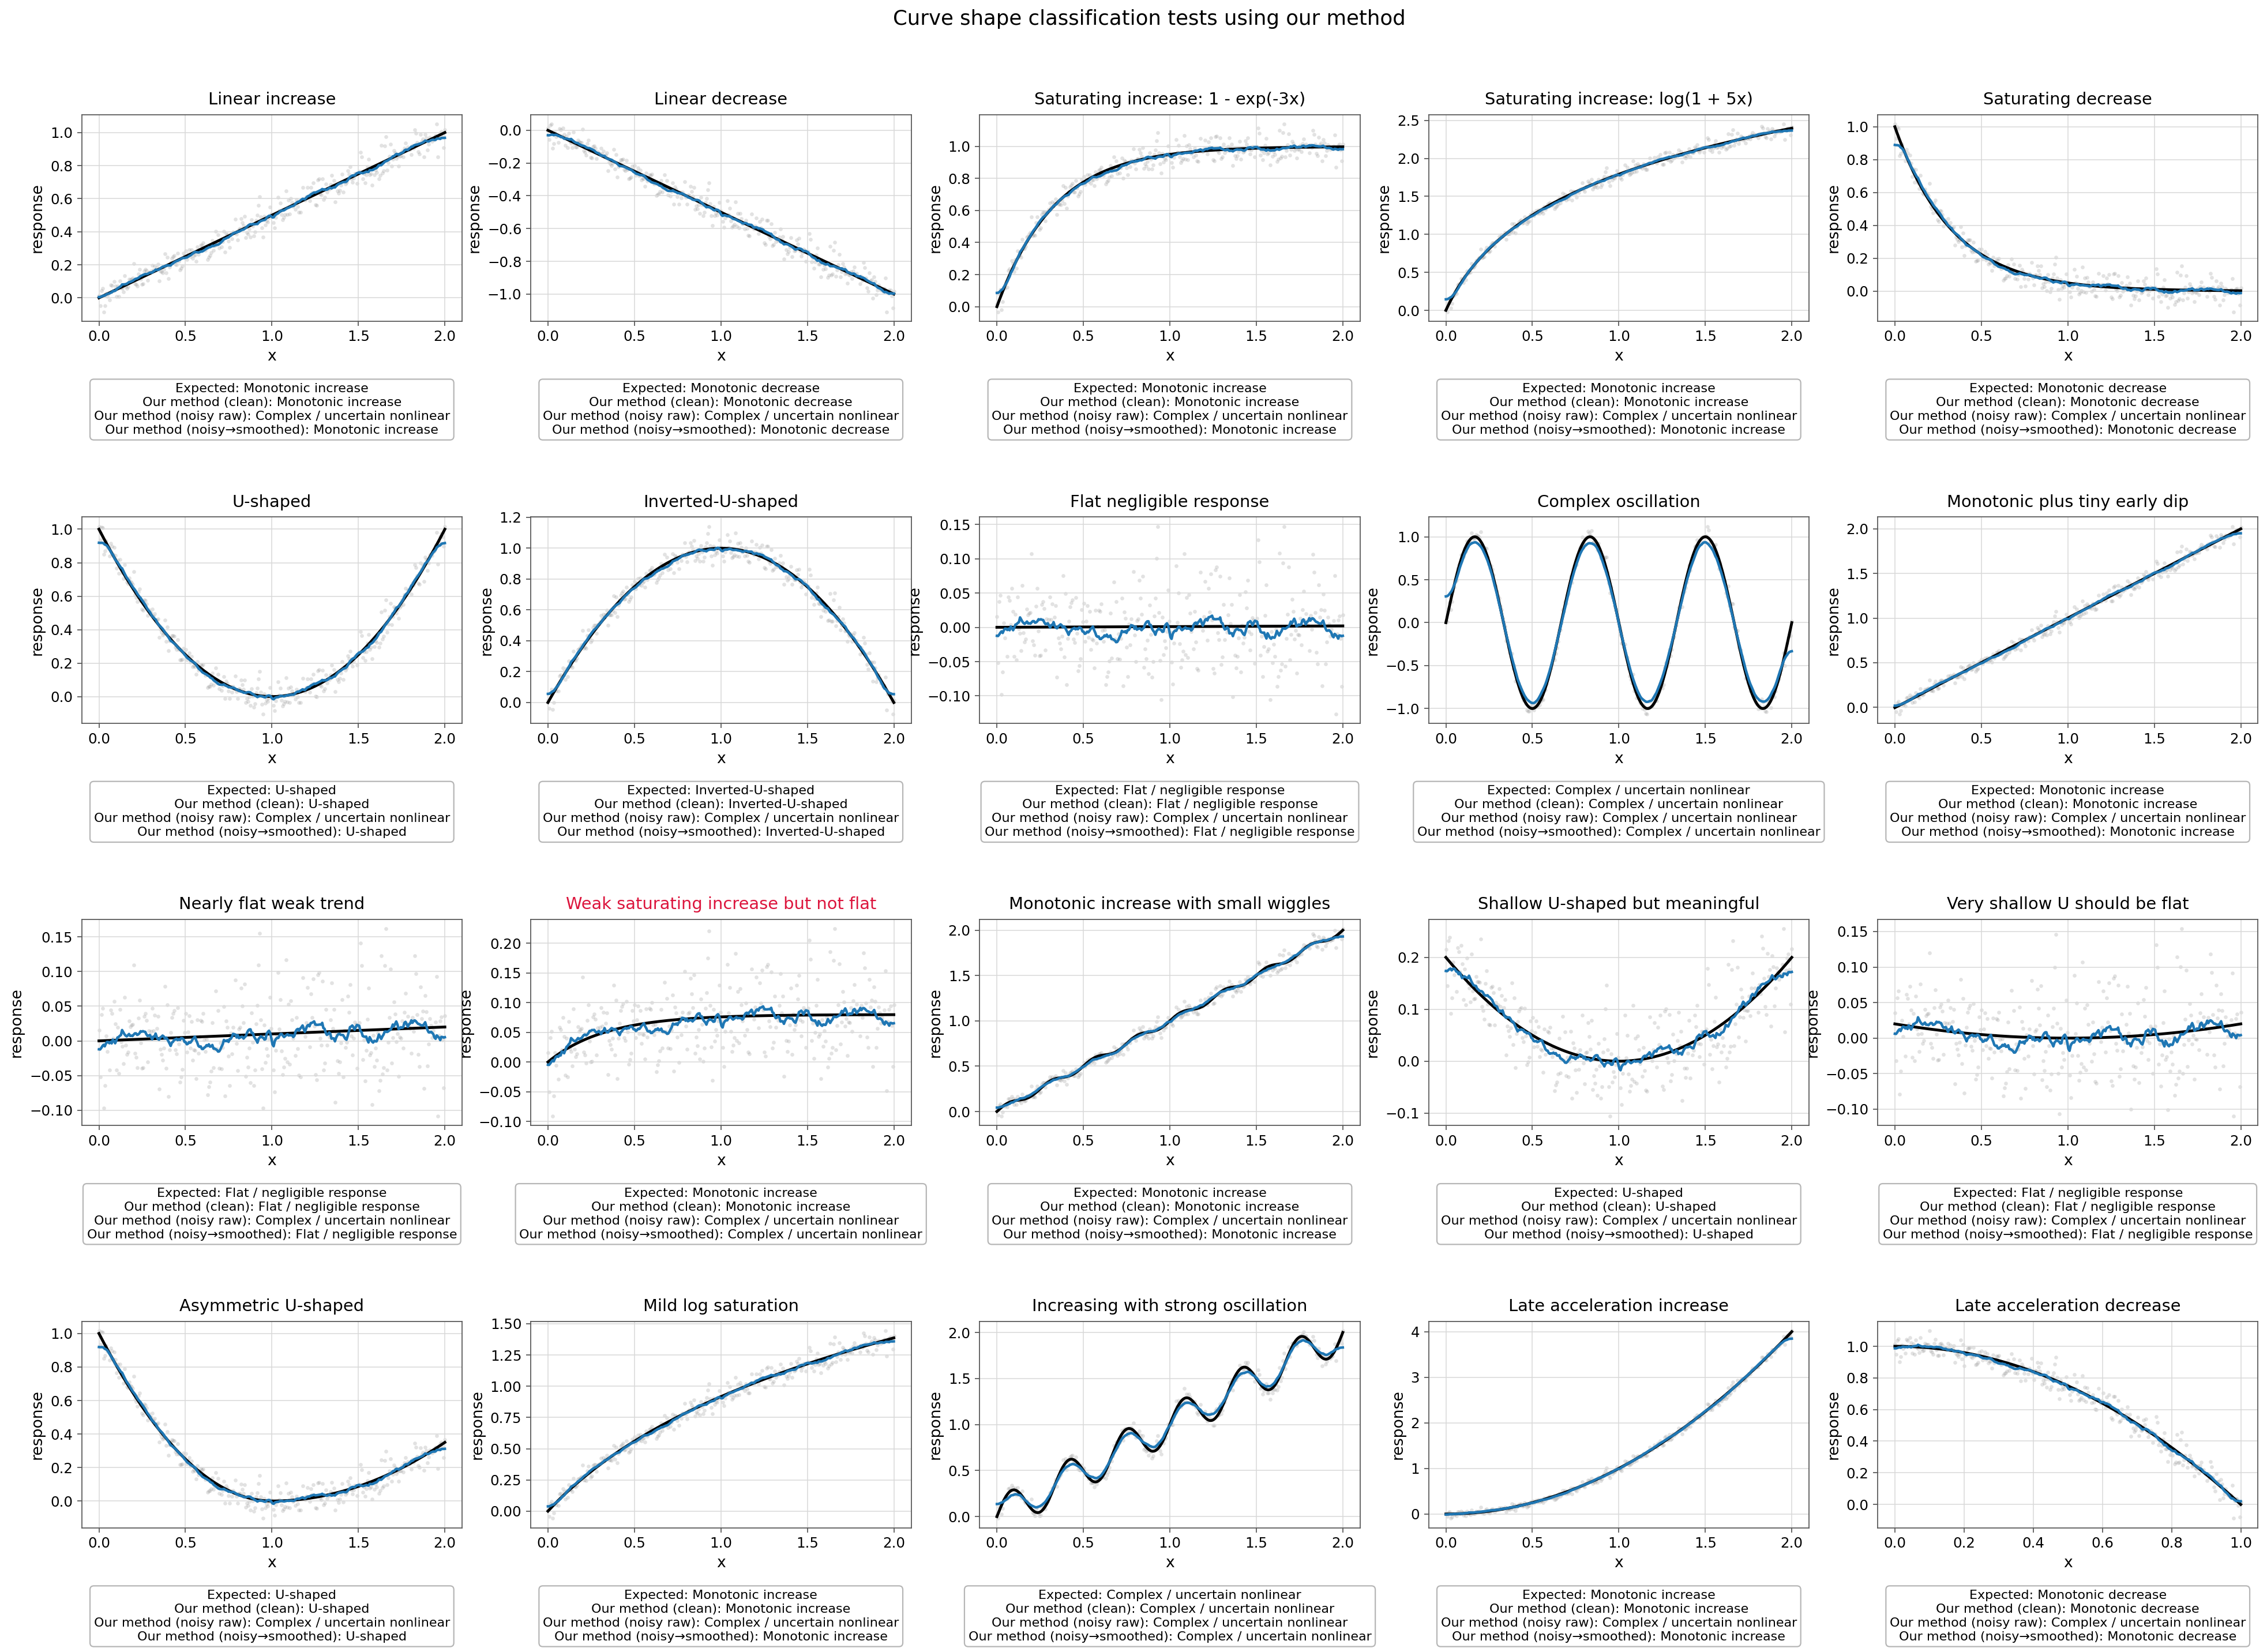


Curve-shape classification result table:


,test_name,expected,our_method_clean,clean_ok,our_method_noisy_raw,noisy_raw_ok,our_method_noisy_smoothed,noisy_smoothed_ok,net_change_clean,pos_fraction_clean,neg_fraction_clean,flat_fraction_clean,n_sign_changes_clean,roughness_ratio_clean,y_range_to_raw_std_clean
0,Linear increase,Monotonic increase,Monotonic increase,True,Complex / uncertain nonlinear,False,Monotonic increase,True,1.00,1.00,0.00,0.00,0.0,1.000000e+00,1.00
1,Linear decrease,Monotonic decrease,Monotonic decrease,True,Complex / uncertain nonlinear,False,Monotonic decrease,True,-1.00,0.00,1.00,0.00,0.0,1.000000e+00,1.00
2,Saturating increase: 1 - exp(-3x),Monotonic increase,Monotonic increase,True,Complex / uncertain nonlinear,False,Monotonic increase,True,1.00,0.88,0.00,0.12,0.0,1.000000e+00,1.00
3,Saturating increase: log(1 + 5x),Monotonic increase,Monotonic increase,True,Complex / uncertain nonlinear,False,Monotonic increase,True,1.00,1.00,0.00,0.00,0.0,1.000000e+00,2.40
4,Saturating decrease,Monotonic decrease,Monotonic decrease,True,Complex / uncertain nonlinear,False,Monotonic decrease,True,-1.00,0.00,0.88,0.12,0.0,1.000000e+00,1.00
5,U-shaped,U-shaped,U-shaped,True,Complex / uncertain nonlinear,False,U-shaped,True,0.00,0.49,0.49,0.01,1.0,2.000000e+09,1.00
6,Inverted-U-shaped,Inverted-U-shaped,Inverted-U-shaped,True,Complex / uncertain nonlinear,False,Inverted-U-shaped,True,0.00,0.49,0.49,0.01,1.0,2.000000e+09,1.00
7,Flat negligible response,Flat / negligible response,Flat / negligible response,True,Complex / uncertain nonlinear,False,Flat / negligible response,True,NaN,NaN,NaN,NaN,NaN,NaN,0.00
8,Complex oscillation,Complex / uncertain nonlinear,Complex / uncertain nonlinear,True,Complex / uncertain nonlinear,True,Complex / uncertain nonlinear,True,-0.00,0.50,0.50,0.00,6.0,5.999115e+09,2.00
9,Monotonic plus tiny early dip,Monotonic increase,Monotonic increase,True,Complex / uncertain nonlinear,False,Monotonic increase,True,1.00,1.00,0.00,0.00,0.0,1.000000e+00,2.00



Accuracy summary:


,case,accuracy
0,clean_ok,100.0
1,noisy_raw_ok,10.0
2,noisy_smoothed_ok,95.0


In [48]:
result_table = plot_test_comparison(
    test_cases=all_test_cases,
    noise=0.05,
    smooth_window=20,
    n_cols=5,
    figsize_per_panel=(5.0, 4.8),
    text_fontsize=10,
    title_fontsize=13,
    axis_label_fontsize=12,
    tick_fontsize=11,
    bottom_text_y=-0.3,
    hspace=0.95,
    print_table=True
)

In [50]:
formal_u_df = run_formal_u_tests_on_synthetic_cases(
    test_cases=all_test_cases,
    noise=0.0,
    n=120,
    alpha=0.05
)

formal_u_df[
    [
        "test_name",
        "expected",
        "Our_method",
        "Our_method_ok",
        "pearson_r",
        "spearman_rho",
        "Lind_Mehlum",
        "Two_line",
        "Order_restricted"
    ]
]

,test_name,expected,Our_method,Our_method_ok,pearson_r,spearman_rho,Lind_Mehlum,Two_line,Order_restricted
0,Linear increase,Monotonic increase,Monotonic increase,True,1.00,1.00,No U-shape detected,No U-shape detected,No U-shape detected
1,Linear decrease,Monotonic decrease,Monotonic decrease,True,-1.00,-1.00,No U-shape detected,No U-shape detected,No U-shape detected
2,Saturating increase: 1 - exp(-3x),Monotonic increase,Monotonic increase,True,0.82,1.00,Inverted-U-shaped,No U-shape detected,No U-shape detected
3,Saturating increase: log(1 + 5x),Monotonic increase,Monotonic increase,True,0.96,1.00,No U-shape detected,No U-shape detected,No U-shape detected
4,Saturating decrease,Monotonic decrease,Monotonic decrease,True,-0.82,-1.00,U-shaped,No U-shape detected,No U-shape detected
5,U-shaped,U-shaped,U-shaped,True,-0.00,-0.01,U-shaped,U-shaped,U-shaped
6,Inverted-U-shaped,Inverted-U-shaped,Inverted-U-shaped,True,0.00,0.01,Inverted-U-shaped,Inverted-U-shaped,Inverted-U-shaped
7,Flat negligible response,Flat / negligible response,Flat / negligible response,True,1.00,1.00,No U-shape detected,No U-shape detected,No U-shape detected
8,Complex oscillation,Complex / uncertain nonlinear,Complex / uncertain nonlinear,True,-0.26,-0.25,No U-shape detected,No U-shape detected,Inverted-U-shaped
9,Monotonic plus tiny early dip,Monotonic increase,Monotonic increase,True,1.00,1.00,No U-shape detected,No U-shape detected,No U-shape detected


In [51]:
formal_u_noisy_df = run_formal_u_tests_on_synthetic_cases(
    test_cases=all_test_cases_simple,
    noise=0.03,
    n=120,
    alpha=0.05
)

formal_u_noisy_df[
[
        "test_name",
        "expected",
        "Our_method",
        "Our_method_ok",
        "pearson_r",
        "spearman_rho",
        "Lind_Mehlum",
        "Two_line",
        "Order_restricted"
    ]
]

,test_name,expected,Our_method,Our_method_ok,pearson_r,spearman_rho,Lind_Mehlum,Two_line,Order_restricted
0,Linear increase,Monotonic increase,Monotonic increase,True,1.00,1.00,No U-shape detected,No U-shape detected,No U-shape detected
1,Linear decrease,Monotonic decrease,Monotonic decrease,True,-1.00,-1.00,No U-shape detected,No U-shape detected,No U-shape detected
2,Saturating increase: 1 - exp(-3x),Monotonic increase,Monotonic increase,True,0.80,0.91,Inverted-U-shaped,No U-shape detected,No U-shape detected
3,Saturating increase: log(1 + 5x),Monotonic increase,Monotonic increase,True,0.96,1.00,No U-shape detected,No U-shape detected,No U-shape detected
4,Saturating decrease,Monotonic decrease,Monotonic decrease,True,-0.82,-0.92,U-shaped,No U-shape detected,No U-shape detected
5,U-shaped,U-shaped,U-shaped,True,-0.01,-0.01,U-shaped,U-shaped,U-shaped
6,Inverted-U-shaped,Inverted-U-shaped,Inverted-U-shaped,True,-0.01,-0.01,Inverted-U-shaped,Inverted-U-shaped,Inverted-U-shaped
7,Flat negligible response,Flat / negligible response,Flat / negligible response,True,-0.10,-0.11,No U-shape detected,No U-shape detected,U-shaped
8,Complex oscillation,Complex / uncertain nonlinear,Complex / uncertain nonlinear,True,-0.26,-0.25,No U-shape detected,No U-shape detected,U-shaped
9,Monotonic plus tiny early dip,Monotonic increase,Monotonic increase,True,1.00,1.00,No U-shape detected,No U-shape detected,No U-shape detected
